# Notebook for the Exploration of the Total Segmentator Dataset

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib # for .nii files
import skimage as skim 
import cv2
from scipy import ndimage

# Define some necessary functions:
def rotated(array_2d):
    list_of_tuples = zip(*array_2d[::-1])
    return [list(elem) for elem in list_of_tuples]

def apply_window(Input,W=1800,L=400):
    min_HU=L-(0.5*W) # lower grey level 
    max_HU=L+(0.5*W) # upper grey level
    Input[Input<min_HU]=min_HU
    Input[Input>max_HU]=max_HU
    return Input

def apply_normalization(Input):
    minimum = Input.min()
    maximum = Input.max()
    Input = (Input - minimum) / (maximum - minimum)
    return Input

def show_yolo_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    with open(label_path, 'r') as f:
        labels = f.readlines()
    for line in labels:
        cls, x, y, bw, bh = map(float, line.strip().split())
        x *= w
        y *= h
        bw *= w
        bh *= h
        xmin = int(x - bw / 2)
        ymin = int(y - bh / 2)
        xmax = int(x + bw / 2)
        ymax = int(y + bh / 2)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 1)
    plt.imshow(img)
    plt.axis('off')
    # plt.savefig('step3.png',bbox_inches='tight')
    plt.show()

In [3]:
# Processed images are located here: 
img_path = '/home/mleeuwen/DATA/TSv3_Selection/Images'
# They are formatted as .nii files

# Corresponding labels are located here: 
label_path = '/home/mleeuwen/DATA/TSv3_Selection/Labels'
# These are also formatted as .nii files

In [4]:
# Check if labels and images match (they do)
all_images = sorted(os.listdir(img_path))
all_labels = sorted(os.listdir(label_path))
print(all_images==all_labels)

True


In [ ]:
# There are 237 scans in total
# Approximate 70-15-15 % split would be: 
#   - train: 1-166 (166 scans)
#   - val: 167-202 (36 scans)
#   - test: 203-237 (35 scans)

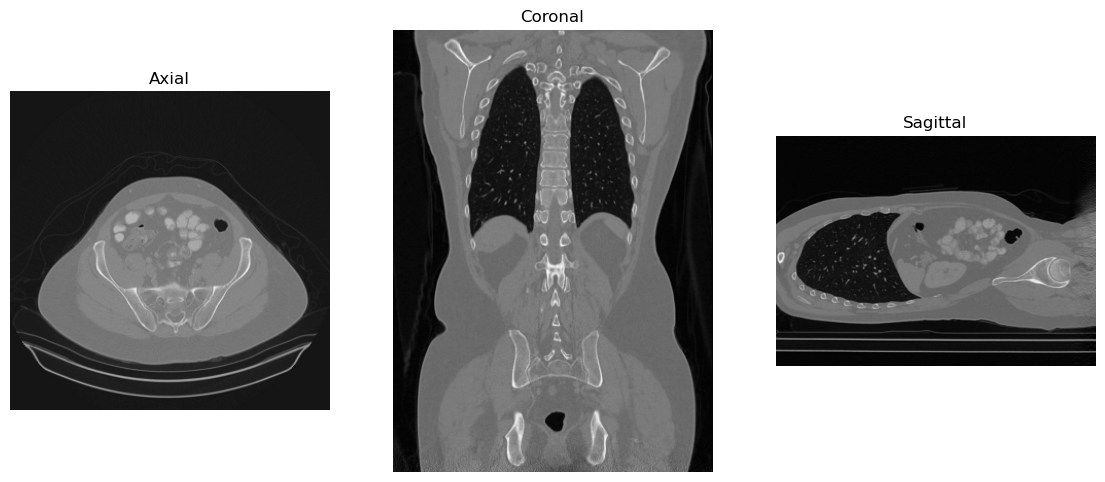

In [6]:
# Load one given scan + its label
scan = 'Scan_0011.nii'

img = nib.load(img_path + '/' + scan)
img_arr = img.get_fdata()
label = nib.load(label_path + '/' + scan)
label_arr = label.get_fdata()

# Display some CT scan slices
idx = 100
slice1 = img_arr[:,:,idx] # top-view
slice2 = img_arr[:,idx,:] # front-view
slice3 = img_arr[idx,:,:] # side-view
slices = [rotated(rotated(slice1.T)), rotated(rotated(slice2.T)), rotated(rotated(slice3))]

fig, axes = plt.subplots(1, 3, figsize=(14, 21))
names = ('Axial', 'Coronal', 'Sagittal')
for i, (s, t) in enumerate(zip(slices, names)):
    axes[i].imshow(s, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(t)

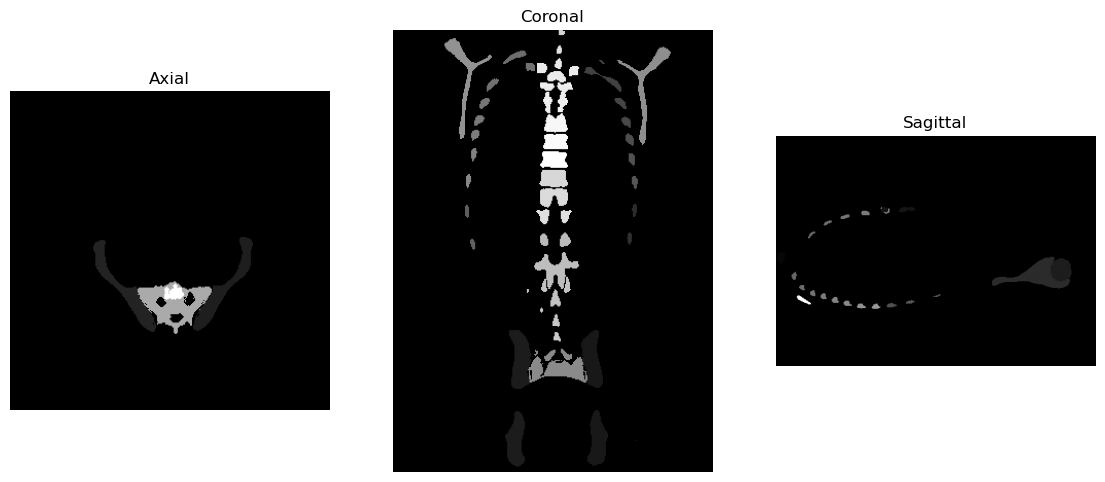

In [11]:
# Display corresponding label slices

slice1 = label_arr[:,:,idx] # top-view
slice2 = label_arr[:,idx,:] # front-view
slice3 = label_arr[idx,:,:] # side-view
slices = [rotated(rotated(slice1.T)), rotated(rotated(slice2.T)), rotated(rotated(slice3))]
fig, axes = plt.subplots(1, 3, figsize=(14, 21))
names = ('Axial', 'Coronal', 'Sagittal')
for i, (s, t) in enumerate(zip(slices, names)):
    axes[i].imshow(s, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(t)

In [14]:
# Bone region properties:

regionprops_slice = label_arr[:,:,idx] 
label = skim.measure.label(regionprops_slice) # Use this function to prevent areas with the same label from being grouped together
info_table = pd.DataFrame(skim.measure.regionprops_table(label.astype(int), properties=['label', 'area', 'centroid', 'bbox'])).reset_index()
info_table = info_table[info_table["area"]>1]
display(info_table)  
 

,index,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3
0,0,1,1109.0,102.233544,118.667268,75,77,133,168
1,1,2,1563.0,151.483685,102.940499,115,74,187,125
3,3,4,195.0,151.338462,113.184615,142,107,161,123
5,5,6,1097.0,199.598906,116.639927,169,76,230,165


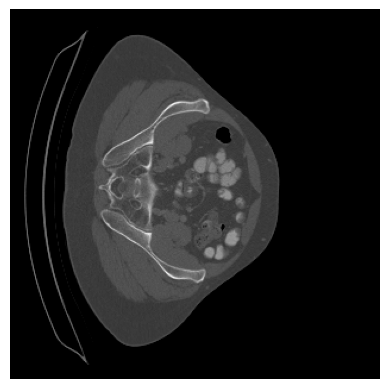

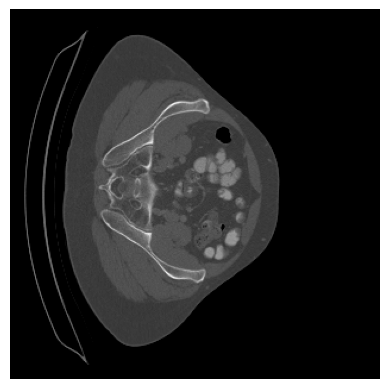

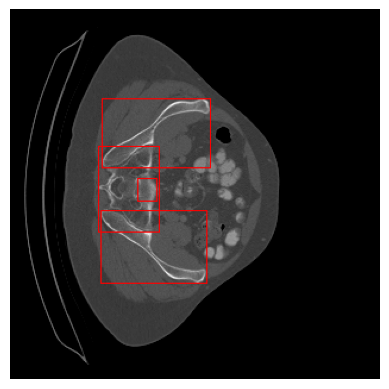

In [10]:
# Visualize pre-processing steps:

# Original Slice
slice = img_arr[:,:,idx] # top-view
# slice = np.rot90(slice)
plt.figure()
plt.imshow(slice, cmap='gray')
plt.axis('off')
# plt.savefig('step1.png',bbox_inches='tight')
plt.show()

# Windowing and min-max normalization
windowed_ct = apply_window(img_arr)
normalized_ct = apply_normalization(windowed_ct)
normalized_slice = normalized_ct[:,:,idx] 
# normalized_slice = np.rot90(normalized_slice)
plt.figure()
plt.imshow(normalized_slice, cmap='gray')
plt.axis('off')
# plt.savefig('step2.png',bbox_inches='tight')
plt.show()

# Bounding boxes
imagepath = '/home/u366836/thesis/DATA/TotalSegmentator/YOLO/images/' 
labelpath = '/home/u366836/thesis/DATA/TotalSegmentator/YOLO/labels/'
x = 'train/0011_top_100'
show_yolo_boxes(imagepath+x+'.png', labelpath+x+'.txt')
